In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np
train=pd.read_csv('/content/drive/MyDrive/cosmic.csv')
train

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Magnetic Field Strength,Radiation Levels,Atmospheric Composition Index,Prediction
0,0.472806,NaN,-0.313872,-2.089299,-0.152201,-0.885649,0.900105,NaN,Category_6,0.692907,5.0
1,4.180154,-1.157515,2.430956,-1.595850,-3.188678,-0.609434,-0.199828,Category_9,Category_9,NaN,0.0
2,-0.129008,1.621592,-0.785741,2.081196,-1.413796,-0.095152,-3.502577,NaN,Category_8,-0.677182,4.0
3,-3.122000,-2.299818,1.072092,0.353524,-0.192529,2.917067,-1.972329,NaN,Category_11,0.109429,1.0
4,-1.459426,2.890268,0.148757,-0.804439,0.494875,0.044910,-0.438796,Category_6,Category_10,0.407941,9.0
...,...,...,...,...,...,...,...,...,...,...,...
59995,-0.316003,-1.160519,0.544548,-1.407123,1.427861,0.849849,-1.932329,Category_8,Category_5,1.333760,8.0
59996,0.789506,-2.645345,-0.375569,-2.579966,0.783195,0.671547,-2.041189,Category_14,Category_4,0.170505,3.0
59997,-0.662563,0.642230,-1.175106,-2.783240,-0.902704,-1.694373,-1.824274,Category_8,Category_8,1.010311,5.0
59998,0.475118,-0.021458,2.086274,1.444825,-1.986595,-2.113147,-0.348915,Category_11,Category_9,-0.665345,6.0


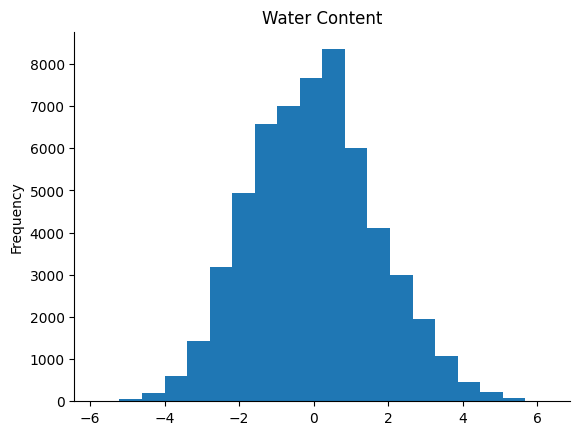

In [23]:
from matplotlib import pyplot as plt
train['Water Content'].plot(kind='hist', bins=20, title='Water Content')
plt.gca().spines[['top', 'right',]].set_visible(False)

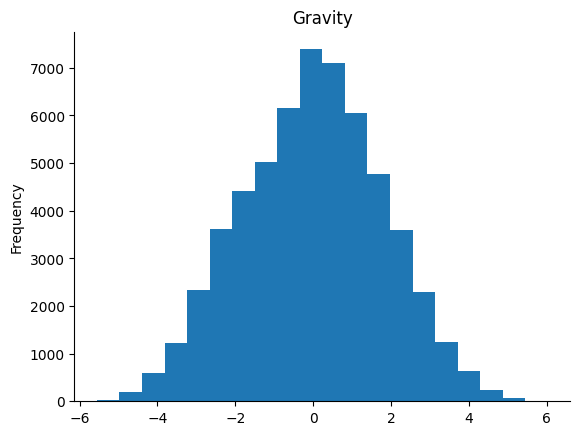

In [24]:
from matplotlib import pyplot as plt
train['Gravity'].plot(kind='hist', bins=20, title='Gravity')
plt.gca().spines[['top', 'right',]].set_visible(False)

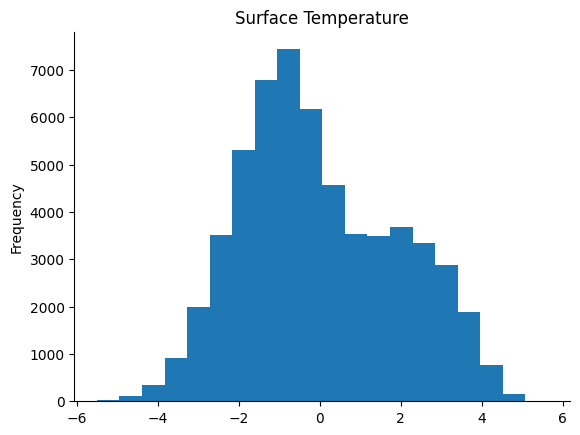

In [25]:
from matplotlib import pyplot as plt
train['Surface Temperature'].plot(kind='hist', bins=20, title='Surface Temperature')
plt.gca().spines[['top', 'right',]].set_visible(False)

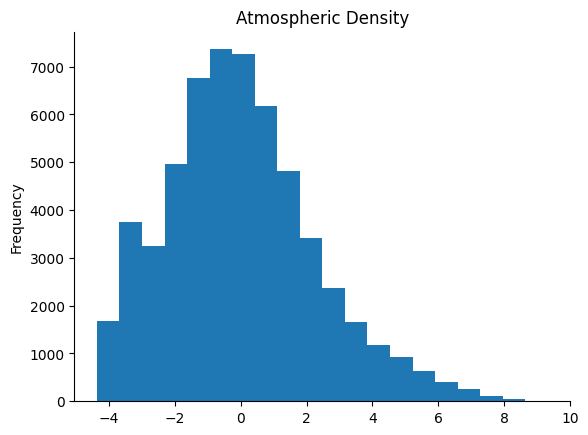

In [26]:
from matplotlib import pyplot as plt
train['Atmospheric Density'].plot(kind='hist', bins=20, title='Atmospheric Density')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [28]:
train = pd.get_dummies(train, columns=["Magnetic Field Strength", "Radiation Levels"])


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
train = train.dropna(subset=['Prediction'])
y = train['Prediction']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
columns =['Atmospheric Density',
'Gravity',
'Water Content',
'Mineral Abundance',
'Orbital Period',
'Proximity to Star',
'Atmospheric Composition Index',
'Prediction']

In [31]:
X_train["Water Content"] = X_train["Water Content"].abs()
X_test["Water Content"] = X_test["Water Content"].abs()

X_train["Mineral Abundance"] = X_train["Mineral Abundance"].abs()
X_test["Mineral Abundance"] = X_test["Mineral Abundance"].abs()


In [32]:
columns_to_fix = ["Atmospheric Density", "Gravity"]

for col in columns_to_fix:
    median_value = train[train[col] > 0][col].median()

    X_train[col] = X_train[col].apply(lambda x: median_value if x < 0 else x)
    X_test[col] = X_test[col].apply(lambda x: median_value if x < 0 else x)

In [33]:
columns_to_fix = ["Surface Temperature", "Orbital Period", "Proximity to Star"]

X_train[columns_to_fix] = X_train[columns_to_fix].abs()
X_test[columns_to_fix] = X_test[columns_to_fix].abs()


In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [35]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

X_train = pd.DataFrame(X_train_transformed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_transformed, columns=X_test.columns, index=X_test.index)


In [ ]:
import pandas as pd
import numpy as np



def remove_outliers_iqr(df, columns=None):
    """
    Remove outliers from a DataFrame using the IQR method.

    Parameters:
    df (pandas.DataFrame): The input DataFrame
    columns (list, optional): List of columns to check for outliers. If None, all numeric columns are used.

    Returns:
    pandas.DataFrame: DataFrame with outliers removed
    """
    df_clean = df.copy()

    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns

    removed_counts = {}

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        before_count = len(df_clean)

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

        after_count = len(df_clean)
        removed_counts[col] = before_count - after_count

    print(f"Total rows in original DataFrame: {len(df)}")
    print(f"Total rows in cleaned DataFrame: {len(df_clean)}")
    print(f"Total outliers removed: {len(df) - len(df_clean)}")
    print("Outliers removed per column:")
    for col, count in removed_counts.items():
        print(f"  - {col}: {count}")

    return df_clean

train = remove_outliers_iqr(train)


In [36]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10),
    max_iter=5,
    random_state=42
)

X_train[:] = imputer.fit_transform(X_train)
X_test[:] = imputer.transform(X_test)
y_train = imputer.fit_transform(y_train.reshape(-1, 1))
y_test = imputer.transform(y_test.reshape(-1, 1))


KeyboardInterrupt: 

In [ ]:


import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report




model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

